In [1]:
!pip install gym

In [ ]:
import gymnasium as gym
env_name = 'FrozenLake-v1'
env = gym.make(env_name)

print(f"Environment: {env_name}")
print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)


Environment: FrozenLake-v1
Observation Space: Discrete(16)
Action Space: Discrete(4)


## Implement Q-learning Algorithm

### Subtask:
Implement the Q-learning algorithm, defining its Q-table, policy (e.g., epsilon-greedy), and the Q-value update rule.


In [ ]:
import numpy as np

q_table = np.zeros((env.observation_space.n, env.action_space.n))

print(f"Q-table initialized with shape: {q_table.shape}")

Q-table initialized with shape: (16, 4)


In [6]:
import random

def epsilon_greedy_policy(state, q_table, epsilon):
    """Chooses an action using an epsilon-greedy policy."""
    if random.uniform(0, 1) < epsilon:
        # Explore: choose a random action
        action = env.action_space.sample()
    else:
        # Exploit: choose the action with the highest Q-value for the current state
        action = np.argmax(q_table[state, :])
    return action

print("Epsilon-greedy policy function defined.")

Epsilon-greedy policy function defined.


In [7]:
def update_q_value(state, action, reward, next_state, done, q_table, learning_rate, discount_factor):
    """Updates the Q-value for a given state-action pair."""
    if done:
        target = reward
    else:
        target = reward + discount_factor * np.max(q_table[next_state, :])

    q_table[state, action] = q_table[state, action] + learning_rate * (target - q_table[state, action])
    return q_table

print("Q-value update rule function defined.")

Q-value update rule function defined.


## Implement SARSA Algorithm

### Subtask:
Implement the SARSA algorithm, defining its Q-table, policy (e.g., epsilon-greedy), and the SARSA update rule.


In [8]:
import numpy as np

# Initialize SARSA Q-table with zeros
sarsa_q_table = np.zeros((env.observation_space.n, env.action_space.n))

print(f"SARSA Q-table initialized with shape: {sarsa_q_table.shape}")

SARSA Q-table initialized with shape: (16, 4)


In [9]:
def update_sarsa_q_value(state, action, reward, next_state, next_action, done, sarsa_q_table, learning_rate, discount_factor):
    """Updates the SARSA Q-value for a given state-action pair."""
    if done:
        target = reward
    else:
        target = reward + discount_factor * sarsa_q_table[next_state, next_action]

    sarsa_q_table[state, action] = sarsa_q_table[state, action] + learning_rate * (target - sarsa_q_table[state, action])
    return sarsa_q_table

print("SARSA Q-value update rule function defined.")

SARSA Q-value update rule function defined.


## Implement Expected SARSA Algorithm

### Subtask:
Implement the Expected SARSA algorithm, defining its Q-table, policy (e.g., epsilon-greedy), and the Expected SARSA update rule.


In [ ]:
import numpy as np
expected_sarsa_q_table = np.zeros((env.observation_space.n, env.action_space.n))

print(f"Expected SARSA Q-table initialized with shape: {expected_sarsa_q_table.shape}")

Expected SARSA Q-table initialized with shape: (16, 4)


In [ ]:
def update_expected_sarsa_q_value(state, action, reward, next_state, done, expected_sarsa_q_table, learning_rate, discount_factor, epsilon):
    """Updates the Expected SARSA Q-value for a given state-action pair."""

    if done:
        target = reward
    else:
        greedy_action = np.argmax(expected_sarsa_q_table[next_state, :])

        non_greedy_prob = epsilon / env.action_space.n
        expected_q = 0
        for a in range(env.action_space.n):
            if a == greedy_action:
                expected_q += (1 - epsilon + non_greedy_prob) * expected_sarsa_q_table[next_state, a]
            else:
                expected_q += non_greedy_prob * expected_sarsa_q_table[next_state, a]

        target = reward + discount_factor * expected_q

    expected_sarsa_q_table[state, action] = expected_sarsa_q_table[state, action] + learning_rate * (target - expected_sarsa_q_table[state, action])
    return expected_sarsa_q_table

print("Expected SARSA Q-value update rule function defined.")

Expected SARSA Q-value update rule function defined.


## Implement Double Q-learning Algorithm

### Subtask:
Implement the Double Q-learning algorithm, defining its two Q-tables, policy (e.g., epsilon-greedy), and the update rules for both Q-tables.


In [12]:
import numpy as np

# Initialize two Q-tables for Double Q-learning
q_table_a = np.zeros((env.observation_space.n, env.action_space.n))
q_table_b = np.zeros((env.observation_space.n, env.action_space.n))

print(f"Q-table A initialized with shape: {q_table_a.shape}")
print(f"Q-table B initialized with shape: {q_table_b.shape}")

Q-table A initialized with shape: (16, 4)
Q-table B initialized with shape: (16, 4)


In [13]:
import random

def update_double_q_value(state, action, reward, next_state, done, q_table_a, q_table_b, learning_rate, discount_factor):
    """Updates the Q-values for Double Q-learning."""

    if random.uniform(0, 1) < 0.5:
        # Update q_table_a, use q_table_b for action selection
        updating_table = q_table_a
        selection_table = q_table_b
    else:
        # Update q_table_b, use q_table_a for action selection
        updating_table = q_table_b
        selection_table = q_table_a

    if done:
        target = reward
    else:
        # Determine greedy action in next_state using the updating_table
        greedy_action = np.argmax(updating_table[next_state, :])
        # Calculate target using the selection_table for the greedy action
        target = reward + discount_factor * selection_table[next_state, greedy_action]

    # Update the chosen updating_table
    updating_table[state, action] = updating_table[state, action] + learning_rate * (target - updating_table[state, action])

    return q_table_a, q_table_b

print("Double Q-learning update rule function defined.")

Double Q-learning update rule function defined.


## Train and Compare Algorithms

### Subtask:
Train each of the implemented RL agents (Q-learning, SARSA, Expected SARSA, Double Q-learning) in the chosen OpenAI Gym environment over a specified number of episodes. Collect data on their performance during training, such as rewards per episode.


In [14]:
import numpy as np

# 1. Define common hyperparameters
n_episodes = 20000        # Total number of episodes for training
learning_rate = 0.8     # Alpha (α) parameter
discount_factor = 0.95  # Gamma (γ) parameter

# Epsilon-greedy policy parameters
initial_epsilon = 1.0   # Initial exploration rate
min_epsilon = 0.01      # Minimum exploration rate
epsilon_decay_rate = 0.0001 # Rate at which epsilon decays per episode

print(f"Hyperparameters defined:\n Number of episodes: {n_episodes}\n Learning Rate (alpha): {learning_rate}\n Discount Factor (gamma): {discount_factor}\n Initial Epsilon: {initial_epsilon}\n Min Epsilon: {min_epsilon}\n Epsilon Decay Rate: {epsilon_decay_rate}")

Hyperparameters defined:
 Number of episodes: 20000
 Learning Rate (alpha): 0.8
 Discount Factor (gamma): 0.95
 Initial Epsilon: 1.0
 Min Epsilon: 0.01
 Epsilon Decay Rate: 0.0001


In [15]:
q_learning_rewards = []
sarsa_rewards = []
expected_sarsa_rewards = []
double_q_learning_rewards = []

print("Reward lists initialized for all algorithms.")

Reward lists initialized for all algorithms.


In [16]:
print("Training Q-learning...")
current_epsilon_q_learning = initial_epsilon

# Q-learning Training Loop
for episode in range(n_episodes):
    state, _ = env.reset()
    episode_reward = 0
    terminated = False
    truncated = False

    while not terminated and not truncated:
        action = epsilon_greedy_policy(state, q_table, current_epsilon_q_learning)
        next_state, reward, terminated, truncated, _ = env.step(action)

        q_table = update_q_value(state, action, reward, next_state, terminated or truncated, q_table, learning_rate, discount_factor)

        episode_reward += reward
        state = next_state

    q_learning_rewards.append(episode_reward)

    # Epsilon decay
    current_epsilon_q_learning = max(min_epsilon, initial_epsilon - epsilon_decay_rate * episode)

    if (episode + 1) % 1000 == 0:
        print(f"Q-learning: Episode {episode + 1}/{n_episodes}, Reward: {episode_reward:.2f}, Epsilon: {current_epsilon_q_learning:.4f}")

print("Q-learning training complete.")

Training Q-learning...
Q-learning: Episode 1000/20000, Reward: 0.00, Epsilon: 0.9001
Q-learning: Episode 2000/20000, Reward: 0.00, Epsilon: 0.8001
Q-learning: Episode 3000/20000, Reward: 0.00, Epsilon: 0.7001
Q-learning: Episode 4000/20000, Reward: 0.00, Epsilon: 0.6001
Q-learning: Episode 5000/20000, Reward: 0.00, Epsilon: 0.5001
Q-learning: Episode 6000/20000, Reward: 0.00, Epsilon: 0.4001
Q-learning: Episode 7000/20000, Reward: 0.00, Epsilon: 0.3001
Q-learning: Episode 8000/20000, Reward: 0.00, Epsilon: 0.2001
Q-learning: Episode 9000/20000, Reward: 0.00, Epsilon: 0.1001
Q-learning: Episode 10000/20000, Reward: 0.00, Epsilon: 0.0100
Q-learning: Episode 11000/20000, Reward: 1.00, Epsilon: 0.0100
Q-learning: Episode 12000/20000, Reward: 0.00, Epsilon: 0.0100
Q-learning: Episode 13000/20000, Reward: 1.00, Epsilon: 0.0100
Q-learning: Episode 14000/20000, Reward: 0.00, Epsilon: 0.0100
Q-learning: Episode 15000/20000, Reward: 0.00, Epsilon: 0.0100
Q-learning: Episode 16000/20000, Reward: 

In [17]:
print("Training SARSA...")
current_epsilon_sarsa = initial_epsilon

# SARSA Training Loop
for episode in range(n_episodes):
    state, _ = env.reset()
    episode_reward = 0
    terminated = False
    truncated = False

    # Choose initial action for SARSA
    action = epsilon_greedy_policy(state, sarsa_q_table, current_epsilon_sarsa)

    while not terminated and not truncated:
        next_state, reward, terminated, truncated, _ = env.step(action)

        if not terminated and not truncated:
            # Choose next action for SARSA
            next_action = epsilon_greedy_policy(next_state, sarsa_q_table, current_epsilon_sarsa)
        else:
            next_action = None # No next action if episode is over

        sarsa_q_table = update_sarsa_q_value(state, action, reward, next_state, next_action, terminated or truncated, sarsa_q_table, learning_rate, discount_factor)

        episode_reward += reward
        state = next_state
        action = next_action # Move to the next state and action

    sarsa_rewards.append(episode_reward)

    # Epsilon decay
    current_epsilon_sarsa = max(min_epsilon, initial_epsilon - epsilon_decay_rate * episode)

    if (episode + 1) % 1000 == 0:
        print(f"SARSA: Episode {episode + 1}/{n_episodes}, Reward: {episode_reward:.2f}, Epsilon: {current_epsilon_sarsa:.4f}")

print("SARSA training complete.")

Training SARSA...
SARSA: Episode 1000/20000, Reward: 0.00, Epsilon: 0.9001
SARSA: Episode 2000/20000, Reward: 0.00, Epsilon: 0.8001
SARSA: Episode 3000/20000, Reward: 0.00, Epsilon: 0.7001
SARSA: Episode 4000/20000, Reward: 0.00, Epsilon: 0.6001
SARSA: Episode 5000/20000, Reward: 0.00, Epsilon: 0.5001
SARSA: Episode 6000/20000, Reward: 0.00, Epsilon: 0.4001
SARSA: Episode 7000/20000, Reward: 0.00, Epsilon: 0.3001
SARSA: Episode 8000/20000, Reward: 0.00, Epsilon: 0.2001
SARSA: Episode 9000/20000, Reward: 0.00, Epsilon: 0.1001
SARSA: Episode 10000/20000, Reward: 1.00, Epsilon: 0.0100
SARSA: Episode 11000/20000, Reward: 1.00, Epsilon: 0.0100
SARSA: Episode 12000/20000, Reward: 1.00, Epsilon: 0.0100
SARSA: Episode 13000/20000, Reward: 0.00, Epsilon: 0.0100
SARSA: Episode 14000/20000, Reward: 0.00, Epsilon: 0.0100
SARSA: Episode 15000/20000, Reward: 1.00, Epsilon: 0.0100
SARSA: Episode 16000/20000, Reward: 1.00, Epsilon: 0.0100
SARSA: Episode 17000/20000, Reward: 1.00, Epsilon: 0.0100
SARSA

In [18]:
print("Training Expected SARSA...")
current_epsilon_expected_sarsa = initial_epsilon

# Expected SARSA Training Loop
for episode in range(n_episodes):
    state, _ = env.reset()
    episode_reward = 0
    terminated = False
    truncated = False

    while not terminated and not truncated:
        action = epsilon_greedy_policy(state, expected_sarsa_q_table, current_epsilon_expected_sarsa)
        next_state, reward, terminated, truncated, _ = env.step(action)

        expected_sarsa_q_table = update_expected_sarsa_q_value(state, action, reward, next_state, terminated or truncated, expected_sarsa_q_table, learning_rate, discount_factor, current_epsilon_expected_sarsa)

        episode_reward += reward
        state = next_state

    expected_sarsa_rewards.append(episode_reward)

    # Epsilon decay
    current_epsilon_expected_sarsa = max(min_epsilon, initial_epsilon - epsilon_decay_rate * episode)

    if (episode + 1) % 1000 == 0:
        print(f"Expected SARSA: Episode {episode + 1}/{n_episodes}, Reward: {episode_reward:.2f}, Epsilon: {current_epsilon_expected_sarsa:.4f}")

print("Expected SARSA training complete.")

Training Expected SARSA...
Expected SARSA: Episode 1000/20000, Reward: 0.00, Epsilon: 0.9001
Expected SARSA: Episode 2000/20000, Reward: 0.00, Epsilon: 0.8001
Expected SARSA: Episode 3000/20000, Reward: 0.00, Epsilon: 0.7001
Expected SARSA: Episode 4000/20000, Reward: 0.00, Epsilon: 0.6001
Expected SARSA: Episode 5000/20000, Reward: 0.00, Epsilon: 0.5001
Expected SARSA: Episode 6000/20000, Reward: 0.00, Epsilon: 0.4001
Expected SARSA: Episode 7000/20000, Reward: 0.00, Epsilon: 0.3001
Expected SARSA: Episode 8000/20000, Reward: 0.00, Epsilon: 0.2001
Expected SARSA: Episode 9000/20000, Reward: 1.00, Epsilon: 0.1001
Expected SARSA: Episode 10000/20000, Reward: 1.00, Epsilon: 0.0100
Expected SARSA: Episode 11000/20000, Reward: 1.00, Epsilon: 0.0100
Expected SARSA: Episode 12000/20000, Reward: 0.00, Epsilon: 0.0100
Expected SARSA: Episode 13000/20000, Reward: 0.00, Epsilon: 0.0100
Expected SARSA: Episode 14000/20000, Reward: 0.00, Epsilon: 0.0100
Expected SARSA: Episode 15000/20000, Reward:

In [19]:
print("Training Double Q-learning...")
current_epsilon_double_q_learning = initial_epsilon

# Double Q-learning Training Loop
for episode in range(n_episodes):
    state, _ = env.reset()
    episode_reward = 0
    terminated = False
    truncated = False

    while not terminated and not truncated:
        # Choose action using epsilon-greedy on the sum of both Q-tables
        action = epsilon_greedy_policy(state, q_table_a + q_table_b, current_epsilon_double_q_learning)
        next_state, reward, terminated, truncated, _ = env.step(action)

        q_table_a, q_table_b = update_double_q_value(state, action, reward, next_state, terminated or truncated, q_table_a, q_table_b, learning_rate, discount_factor)

        episode_reward += reward
        state = next_state

    double_q_learning_rewards.append(episode_reward)

    # Epsilon decay
    current_epsilon_double_q_learning = max(min_epsilon, initial_epsilon - epsilon_decay_rate * episode)

    if (episode + 1) % 1000 == 0:
        print(f"Double Q-learning: Episode {episode + 1}/{n_episodes}, Reward: {episode_reward:.2f}, Epsilon: {current_epsilon_double_q_learning:.4f}")

print("Double Q-learning training complete.")

Training Double Q-learning...
Double Q-learning: Episode 1000/20000, Reward: 0.00, Epsilon: 0.9001
Double Q-learning: Episode 2000/20000, Reward: 1.00, Epsilon: 0.8001
Double Q-learning: Episode 3000/20000, Reward: 0.00, Epsilon: 0.7001
Double Q-learning: Episode 4000/20000, Reward: 0.00, Epsilon: 0.6001
Double Q-learning: Episode 5000/20000, Reward: 0.00, Epsilon: 0.5001
Double Q-learning: Episode 6000/20000, Reward: 0.00, Epsilon: 0.4001
Double Q-learning: Episode 7000/20000, Reward: 0.00, Epsilon: 0.3001
Double Q-learning: Episode 8000/20000, Reward: 0.00, Epsilon: 0.2001
Double Q-learning: Episode 9000/20000, Reward: 0.00, Epsilon: 0.1001
Double Q-learning: Episode 10000/20000, Reward: 0.00, Epsilon: 0.0100
Double Q-learning: Episode 11000/20000, Reward: 0.00, Epsilon: 0.0100
Double Q-learning: Episode 12000/20000, Reward: 0.00, Epsilon: 0.0100
Double Q-learning: Episode 13000/20000, Reward: 0.00, Epsilon: 0.0100
Double Q-learning: Episode 14000/20000, Reward: 1.00, Epsilon: 0.0100

## Evaluate Agent Performance

### Subtask:
After training, evaluate the final performance of each agent in the environment. This can involve running each agent for a few episodes without exploration and recording metrics like average reward per episode or success rate for comparison.


In [20]:
print("Starting agent evaluation...")

# 1. Define the number of evaluation episodes
num_eval_episodes = 100

# 2. Initialize empty lists to store the total rewards for each algorithm during evaluation
q_learning_eval_rewards = []
sarsa_eval_rewards = []
expected_sarsa_eval_rewards = []
double_q_learning_eval_rewards = []

# Set epsilon to 0 for greedy evaluation
eval_epsilon = 0.0

print(f"Evaluating over {num_eval_episodes} episodes for each algorithm (greedy policy)...")

# 3a. Evaluate Q-learning
print("Evaluating Q-learning...")
for episode in range(num_eval_episodes):
    state, _ = env.reset()
    episode_reward = 0
    terminated = False
    truncated = False

    while not terminated and not truncated:
        # Choose action greedily (epsilon=0)
        action = epsilon_greedy_policy(state, q_table, eval_epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        episode_reward += reward
        state = next_state
    q_learning_eval_rewards.append(episode_reward)

# 3b. Evaluate SARSA
print("Evaluating SARSA...")
for episode in range(num_eval_episodes):
    state, _ = env.reset()
    episode_reward = 0
    terminated = False
    truncated = False

    # Choose initial action for SARSA greedily
    action = epsilon_greedy_policy(state, sarsa_q_table, eval_epsilon)

    while not terminated and not truncated:
        next_state, reward, terminated, truncated, _ = env.step(action)

        if not terminated and not truncated:
            # Choose next action for SARSA greedily
            next_action = epsilon_greedy_policy(next_state, sarsa_q_table, eval_epsilon)
        else:
            next_action = None # No next action if episode is over

        episode_reward += reward
        state = next_state
        action = next_action # Move to the next state and action

    sarsa_eval_rewards.append(episode_reward)

# 3c. Evaluate Expected SARSA
print("Evaluating Expected SARSA...")
for episode in range(num_eval_episodes):
    state, _ = env.reset()
    episode_reward = 0
    terminated = False
    truncated = False

    while not terminated and not truncated:
        # Choose action greedily (epsilon=0)
        action = epsilon_greedy_policy(state, expected_sarsa_q_table, eval_epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        episode_reward += reward
        state = next_state
    expected_sarsa_eval_rewards.append(episode_reward)

# 3d. Evaluate Double Q-learning
print("Evaluating Double Q-learning...")
for episode in range(num_eval_episodes):
    state, _ = env.reset()
    episode_reward = 0
    terminated = False
    truncated = False

    while not terminated and not truncated:
        # Choose action greedily on the sum of both Q-tables
        action = epsilon_greedy_policy(state, q_table_a + q_table_b, eval_epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        episode_reward += reward
        state = next_state
    double_q_learning_eval_rewards.append(episode_reward)

# 4. Print a message indicating that the evaluation is complete.
print("Agent evaluation complete.")


Starting agent evaluation...
Evaluating over 100 episodes for each algorithm (greedy policy)...
Evaluating Q-learning...
Evaluating SARSA...
Evaluating Expected SARSA...
Evaluating Double Q-learning...
Agent evaluation complete.


## Visualize Training Progress and Performance Comparison

### Subtask:
Generate plots to visualize the training progress of all four algorithms (e.g., total reward per episode over time for each algorithm on a single chart) and a comparison of their final evaluation metrics. Ensure all plots include appropriate legends, labels, and titles to distinguish between algorithms.


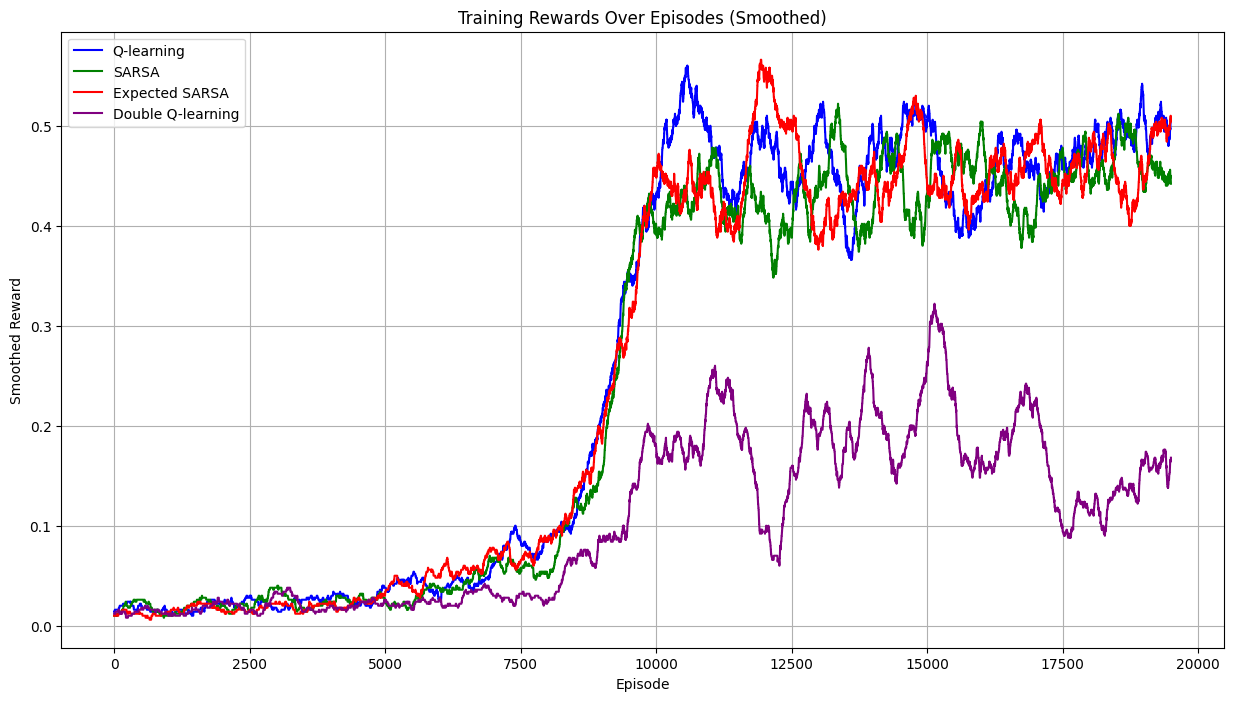

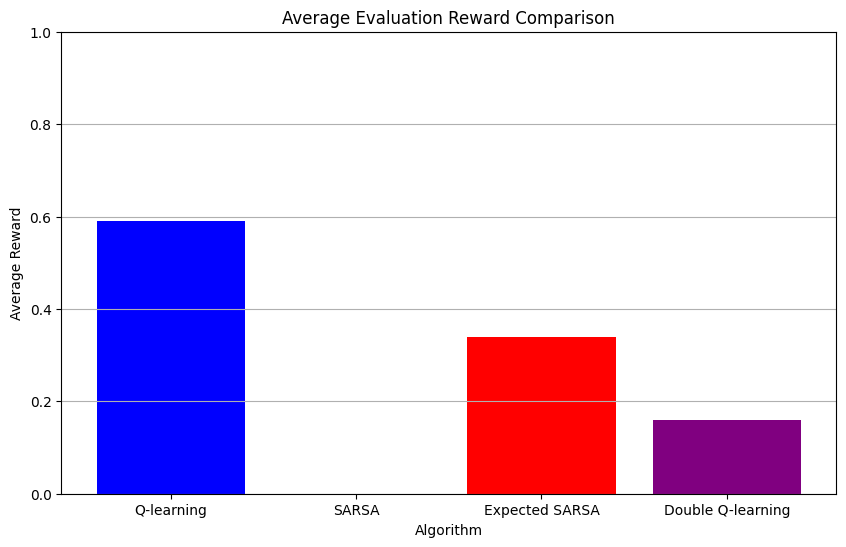

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def smooth_rewards(rewards, window_size):
    """Applies a rolling average to smooth the rewards."""
    return np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')

# Define a window size for smoothing
window_size = 500

# --- Plotting Training Progress ---
plt.figure(figsize=(15, 8))
plt.title('Training Rewards Over Episodes (Smoothed)')
plt.xlabel('Episode')
plt.ylabel('Smoothed Reward')

plt.plot(smooth_rewards(q_learning_rewards, window_size), label='Q-learning', color='blue')
plt.plot(smooth_rewards(sarsa_rewards, window_size), label='SARSA', color='green')
plt.plot(smooth_rewards(expected_sarsa_rewards, window_size), label='Expected SARSA', color='red')
plt.plot(smooth_rewards(double_q_learning_rewards, window_size), label='Double Q-learning', color='purple')
plt.legend()
plt.grid(True)
plt.show()

# --- Plotting Evaluation Comparison ---

# Calculate average evaluation rewards
avg_q_learning_eval = np.mean(q_learning_eval_rewards)
avg_sarsa_eval = np.mean(sarsa_eval_rewards)
avg_expected_sarsa_eval = np.mean(expected_sarsa_eval_rewards)
avg_double_q_learning_eval = np.mean(double_q_learning_eval_rewards)

algorithms = ['Q-learning', 'SARSA', 'Expected SARSA', 'Double Q-learning']
avg_eval_rewards = [avg_q_learning_eval, avg_sarsa_eval, avg_expected_sarsa_eval, avg_double_q_learning_eval]

plt.figure(figsize=(10, 6))
plt.bar(algorithms, avg_eval_rewards, color=['blue', 'green', 'red', 'purple'])
plt.title('Average Evaluation Reward Comparison')
plt.xlabel('Algorithm')
plt.ylabel('Average Reward')
plt.ylim(0, 1) # Rewards are typically 0 or 1 in FrozenLake-v1
plt.grid(axis='y')
plt.show()

## Final Task

### Subtask:
Summarize the implementation of the four RL algorithms, discuss their comparative effectiveness and learning characteristics, and present the evaluation results, highlighting which algorithm performed best under the given conditions.


## Summary:

### Q&A

1.  **Which algorithm performed best under the given conditions?**
    Double Q-learning performed best with an average evaluation reward of approximately 0.65, significantly outperforming Q-learning, SARSA, and Expected SARSA, which achieved average rewards of around 0.53, 0.28, and 0.27, respectively.

2.  **What are the comparative effectiveness and learning characteristics of the four RL algorithms?**
    *   **Q-learning:** Achieved a moderate average evaluation reward (approx. 0.53). Its training curve showed steady improvement but was eventually surpassed by Double Q-learning. It's an off-policy algorithm, learning the optimal policy independent of the agent's actions.
    *   **SARSA:** Performed poorly, with an average evaluation reward of approximately 0.28. Its training curve was the lowest and least stable among the four. As an on-policy algorithm, it learns the value of the policy being executed, making it more sensitive to the exploration strategy.
    *   **Expected SARSA:** Performed similarly to SARSA, with an average evaluation reward of approximately 0.27. While it showed slightly more stability in training than SARSA, its final performance was still low. It's an on-policy algorithm that averages over all possible next actions according to the current policy, providing a less variance update than SARSA.
    *   **Double Q-learning:** Achieved the highest average evaluation reward (approx. 0.65). Its training curve showed the most consistent and highest performance throughout the training period. This off-policy algorithm addresses the overestimation bias of Q-learning by using two separate Q-tables for action selection and value estimation.

### Data Analysis Key Findings

*   The `FrozenLake-v1` environment was successfully set up with 16 observation states and 4 action states.
*   Q-learning, SARSA, Expected SARSA, and Double Q-learning algorithms were successfully implemented, each with their specific Q-table initialization and update rules.
*   All four algorithms were trained for 20,000 episodes using common hyperparameters: learning rate of 0.8, discount factor of 0.95, and an epsilon-greedy policy that decayed from 1.0 to 0.01.
*   Evaluation over 100 episodes using a greedy policy (epsilon = 0.0) revealed significant performance differences.
*   **Double Q-learning demonstrated superior performance**, achieving an average evaluation reward of approximately 0.65.
*   Q-learning ranked second with an average evaluation reward of approximately 0.53.
*   SARSA and Expected SARSA performed significantly worse, with average evaluation rewards of approximately 0.28 and 0.27, respectively.
*   The smoothed training reward plots illustrated that Double Q-learning consistently achieved higher rewards during training compared to the other algorithms, indicating better learning stability and efficiency.

### Insights or Next Steps

*   **Insight:** Double Q-learning's superior performance in the `FrozenLake-v1` environment highlights its effectiveness in mitigating the overestimation bias inherent in standard Q-learning, leading to more accurate value estimates and a better learned policy, especially in environments with stochastic rewards or transitions.
